In [174]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize']=(12,6)

In [175]:
df = pd.read_csv('netflix.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [177]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [178]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [179]:
df.shape

(8807, 12)

In [180]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

In [181]:
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [182]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Handling Missing Values

In [183]:
df['director']=df['director'].fillna('Unknown')
df['director'].head()

0    Kirsten Johnson
1            Unknown
2    Julien Leclercq
3            Unknown
4            Unknown
Name: director, dtype: object

### why not to use mode here even it is an categorical feature, as the mode will take most occuring director, means even if the director not directed the memory, the movie will assign to him....

In [184]:
df['cast']=df['cast'].fillna('Unknown')
df['cast'].head()

0                                              Unknown
1    Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2    Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                              Unknown
4    Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
Name: cast, dtype: object

In [185]:
df['country']=df['country'].fillna('Unknown')
df['country'].head()

0    United States
1     South Africa
2          Unknown
3          Unknown
4            India
Name: country, dtype: object

In [186]:
df['date_added']=df['date_added'].fillna('Unknown')
df['date_added'].head()

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: object

### For Rating and Duration I Can Use Mode instead of 'Unknown', Cause It has Very Less Null Values, So it will not affect the Dataset

In [187]:
df['rating'].mode()

0    TV-MA
Name: rating, dtype: object

In [188]:
df['rating']=df['rating'].fillna(df['rating'].mode()[0])
df['rating'].head()

0    PG-13
1    TV-MA
2    TV-MA
3    TV-MA
4    TV-MA
Name: rating, dtype: object

In [189]:
df['duration']=df['duration'].fillna(df['duration'].mode()[0])
df['duration'].head()

0       90 min
1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
Name: duration, dtype: object

In [190]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [191]:
# Checked Duplicate Values, Means Any Whole Row is duplicated so i can drop it...
df.duplicated().sum()

np.int64(0)

In [192]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Univariate Analysis

### The Feature which are not useful for our ml model and can be ignored for analysis
### show_id, title, description

In [193]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

C:\Users\Anurag\AppData\Local\Temp\ipykernel_18328\3118464840.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type',data=df,palette=['Red','Green'])


<Axes: xlabel='type', ylabel='count'>

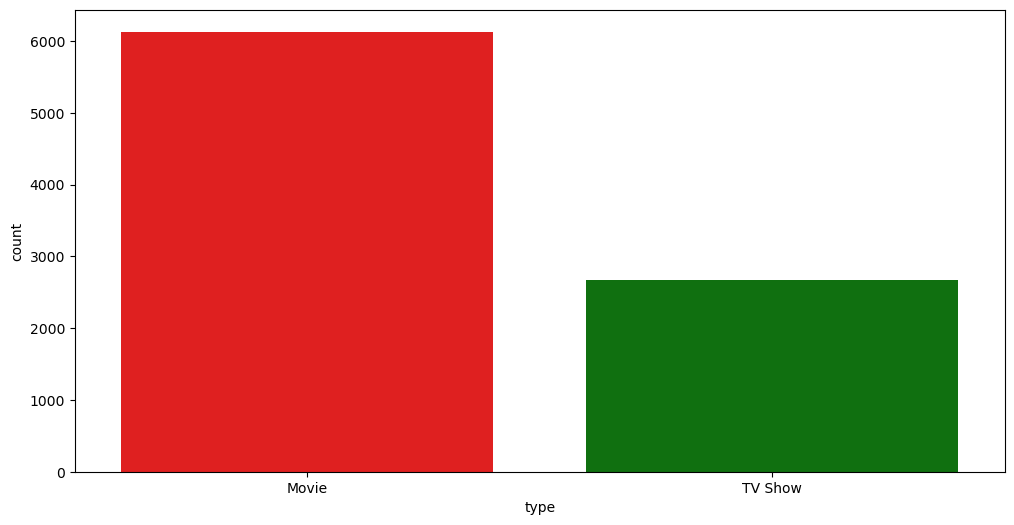

In [194]:
sns.countplot(x='type',data=df,palette=['Red','Green'])

### Observation : The Most of the netflix releases are the type Movie than TV Shows

### Observation : lots of data not working instead we can do like this,

<Axes: ylabel='director'>

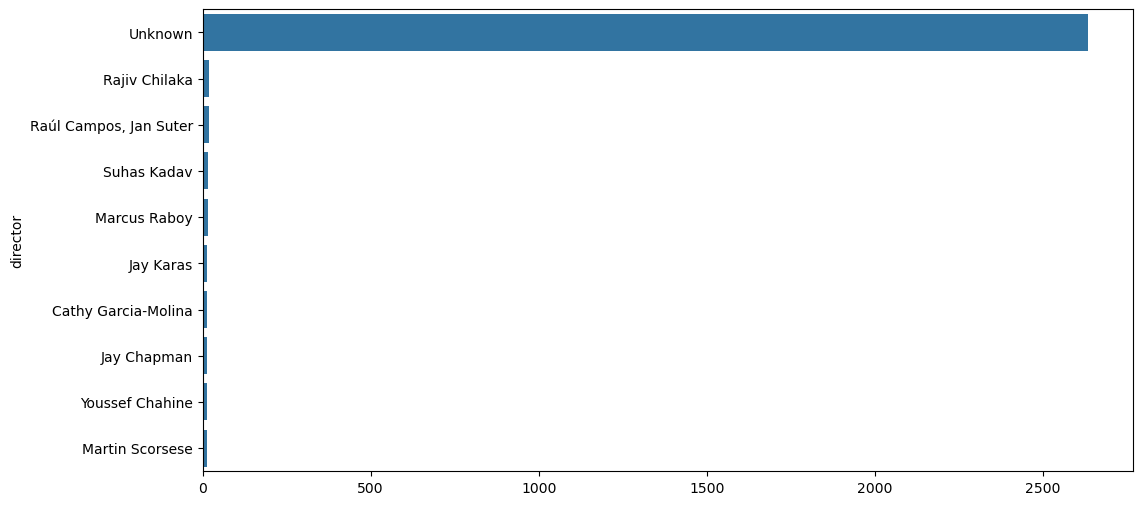

In [195]:
top_directors = df['director'].value_counts().head(10)

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

### Observation : As, in the plot there are lots of unknown director than know

In [196]:
df['cast'].nunique()

7693

In [197]:
df['cast'].value_counts().head(10)

cast
Unknown                                                                                                                   825
David Attenborough                                                                                                         19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil                                    14
Samuel West                                                                                                                10
Jeff Dunham                                                                                                                 7
Craig Sechler                                                                                                               6
David Spade, London Hughes, Fortune Feimster                                                                                6
Kevin Hart                                                                                                       

### Observation : lots of data not working instead we can do like this, 1st we how total cast is there and then we see top 10 cast who are reapted most

In [198]:
df['country'].nunique()

749

In [199]:
df['country'].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

<Axes: xlabel='country', ylabel='count'>

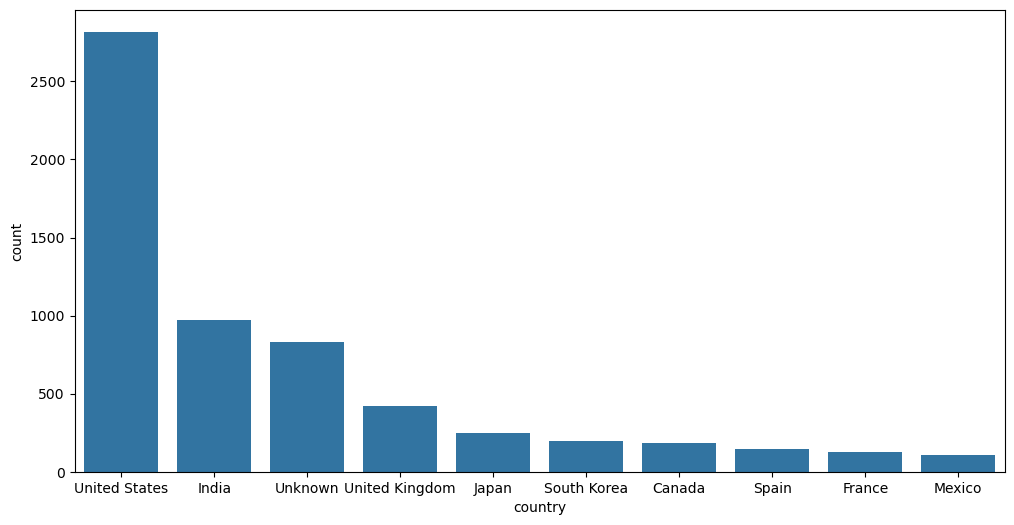

In [200]:
sns.countplot(
    x='country',
    data=df,
    order=df['country'].value_counts().head(10).index
)
# order is to print the countries with most releases in order ascending

### Observation :  lots of data not working instead we can do like this, the most of the netflix releases are from US

<Axes: xlabel='date_added', ylabel='count'>

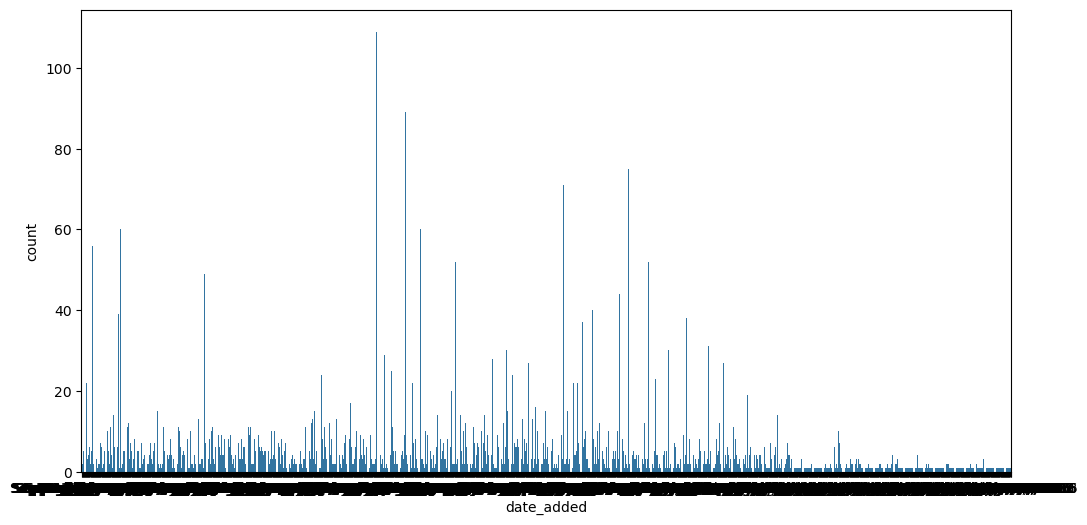

In [201]:
sns.countplot(x='date_added',data=df)

### Observation : unable to plot the unique values, intsead we to above things,

In [202]:
# Better approach Convert it to datetime:
# If Pandas finds a value that cannot be converted to a date, don't raise an error. Instead, convert it to NaT (Not a Time).
# pd.to_datetime() is a Pandas function that converts data into a datetime (date-time) datatype.
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['date_added'].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [203]:
# Then extract: Year Added
df['year_added'] = df['date_added'].dt.year
df['year_added'].head()

0    2021.0
1    2021.0
2    2021.0
3    2021.0
4    2021.0
Name: year_added, dtype: float64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2008.0'),
  Text(1, 0, '2009.0'),
  Text(2, 0, '2010.0'),
  Text(3, 0, '2011.0'),
  Text(4, 0, '2012.0'),
  Text(5, 0, '2013.0'),
  Text(6, 0, '2014.0'),
  Text(7, 0, '2015.0'),
  Text(8, 0, '2016.0'),
  Text(9, 0, '2017.0'),
  Text(10, 0, '2018.0'),
  Text(11, 0, '2019.0'),
  Text(12, 0, '2020.0'),
  Text(13, 0, '2021.0')])

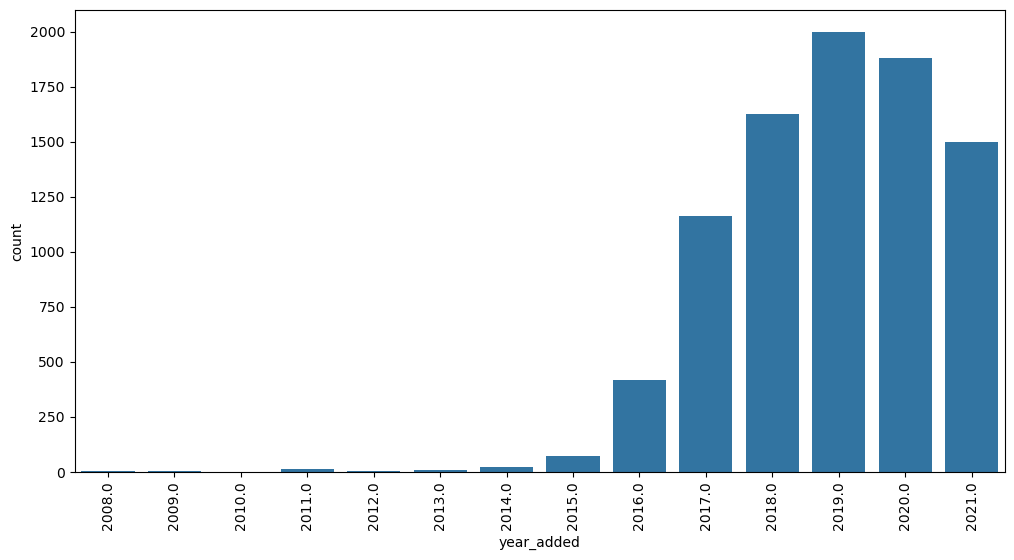

In [204]:
sns.countplot(x='year_added', data=df)
plt.xticks(rotation=90) # plt.xticks(rotation=90) is used to rotate the labels on the x-axis.

### Observation : The plot shows that the netflix has the most releases in these year 2021

In [205]:
df['release_year']

0       2020
1       2021
2       2021
3       2021
4       2021
        ... 
8802    2007
8803    2018
8804    2009
8805    2006
8806    2015
Name: release_year, Length: 8807, dtype: int64

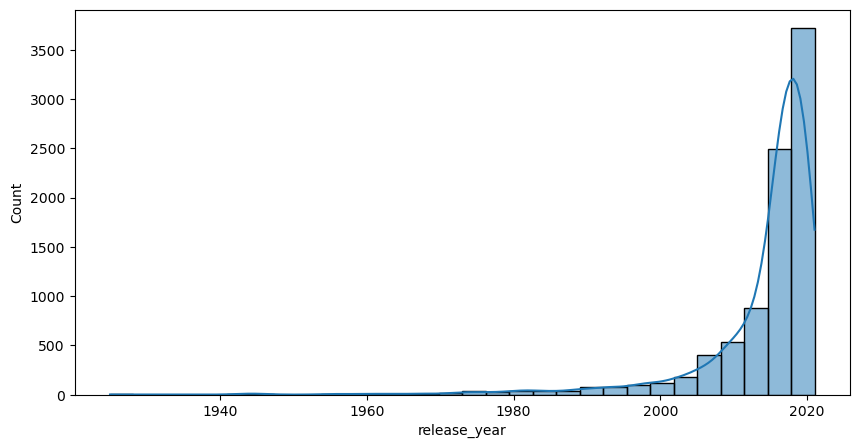

In [206]:
plt.figure(figsize=(10,5))
sns.histplot(x='release_year', data=df, bins=30, kde=True)
plt.show()
# bins=30 - how many group intervals data should divided into ex- 2019-2020, 2020-2021

### Observation : TV-MA is the rating given by most of the peoples, this means the content made by netflix is more TV-Mature Audience

In [207]:
df['duration'].value_counts().head(10)

duration
1 Season     1796
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64

<Axes: xlabel='duration'>

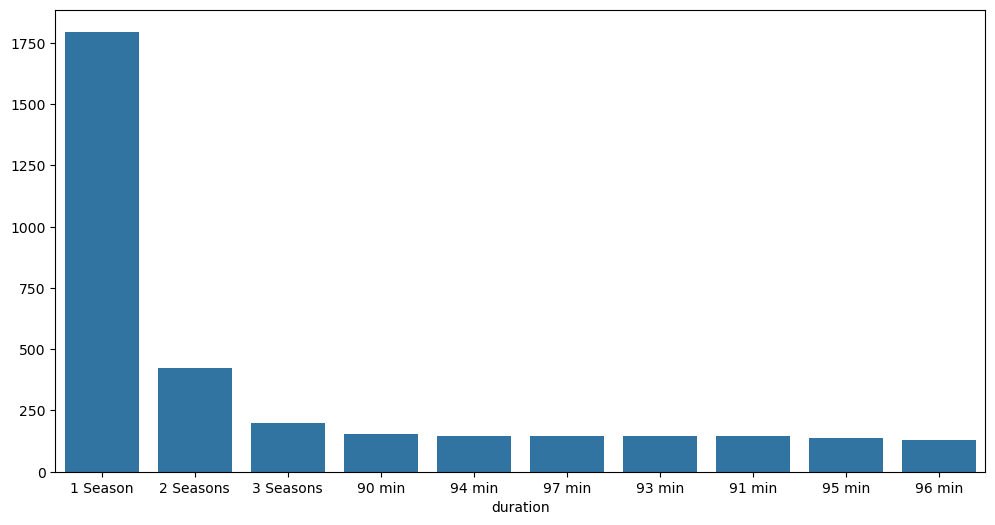

In [208]:
top_duration = df['duration'].value_counts().head(10)

sns.barplot(
    y=top_duration.values,
    x=top_duration.index
)

### Observation : There is lots of data, so i use top 10 duration, the highest duration in netflix releases has 1 Season only

In [209]:
df['listed_in'].nunique()

514

<Axes: ylabel='listed_in'>

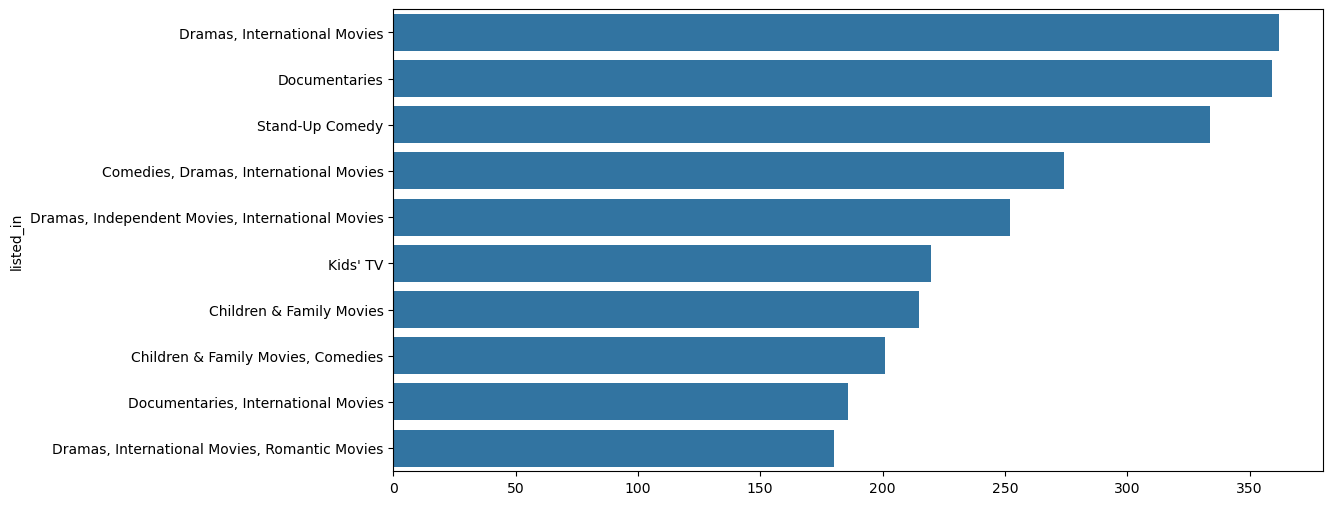

In [210]:
top_genres = df['listed_in'].value_counts().head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

### Observation : The top 10 netflix listed in releases are in Dramas, International Movies

# Bivariate Analysis

In [211]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


([0, 1], [Text(0, 0, 'Movie'), Text(1, 0, 'TV Show')])

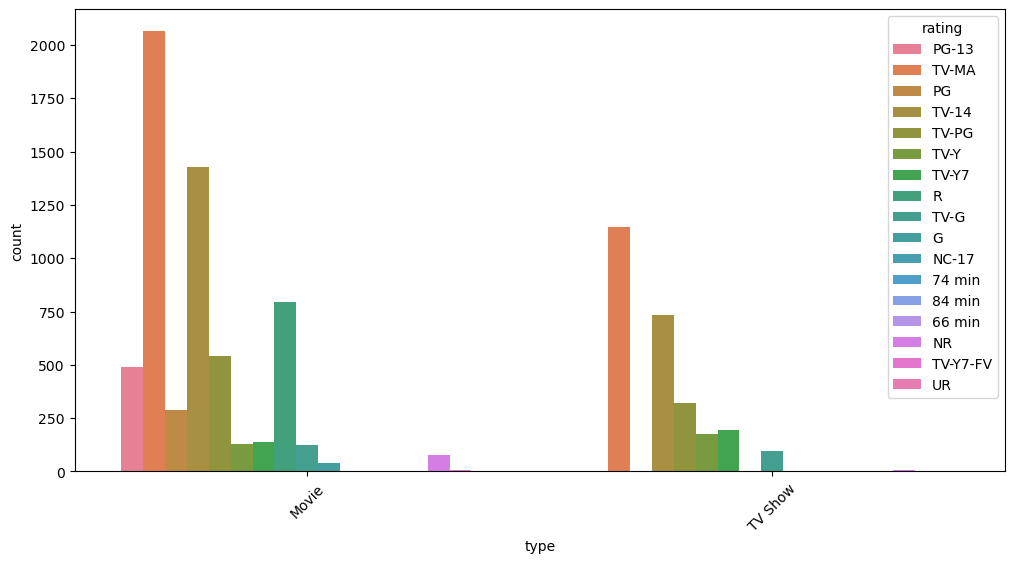

In [212]:
sns.countplot(x='type', hue='rating', data=df)
plt.xticks(rotation=45)

### Observation : TV-MA (TV Mature Audience) is the most common rating for both Movies and TV Shows on Netflix. This suggests that a large portion of Netflix's content is intended for mature audiences and may contain strong language, violence, sexual content, or other adult themes.

In [213]:
# we have extracted the top 10 directors values_count = gives no. of values, index= labels (director names)
top_directors = df['director'].value_counts().head(10).index

<Axes: xlabel='count', ylabel='director'>

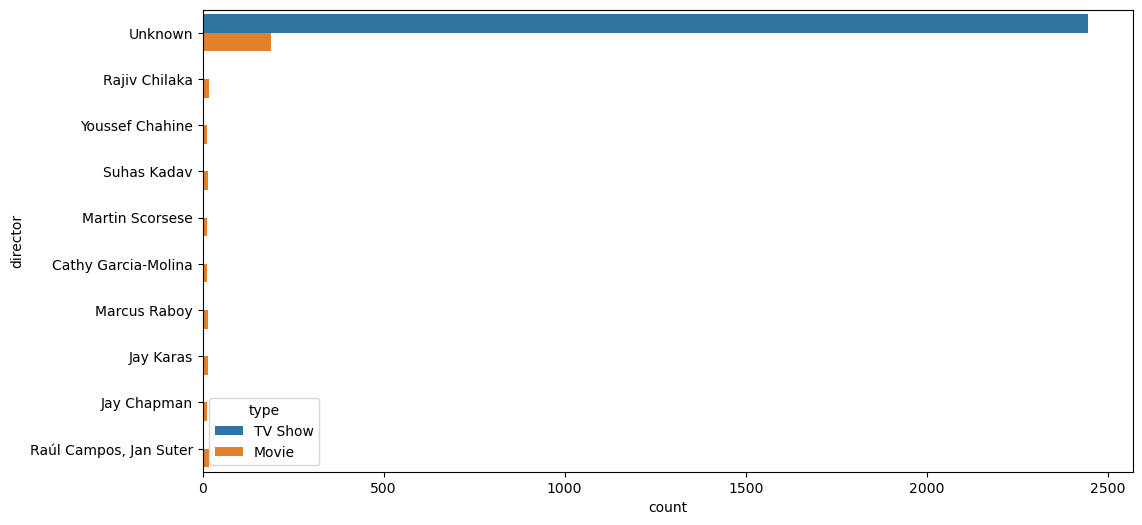

In [214]:
filtered_df = df[df['director'].isin(top_directors)]

sns.countplot(y='director',hue='type',data=filtered_df)

### top_directors contains the names of the Top 10 directors.
### df['director'].isin(top_directors)
### Checks each director.
### Returns True if the director is in Top 10.
### Returns False otherwise.
### df[...]
### Keeps rows with True.
### Removes rows with False.
### filtered_df
### New DataFrame containing only movies/shows directed by the Top 10 directors.
## Observation : The most of the netflix releases are TV shows then Movie, and the most of the directors are 'Unknown' for it

In [215]:
# we have extracted the top 10 countries values_count = gives no. of values, index= labels (country names)
top_countries =df['country'].value_counts().head(10).index

<Axes: xlabel='count', ylabel='country'>

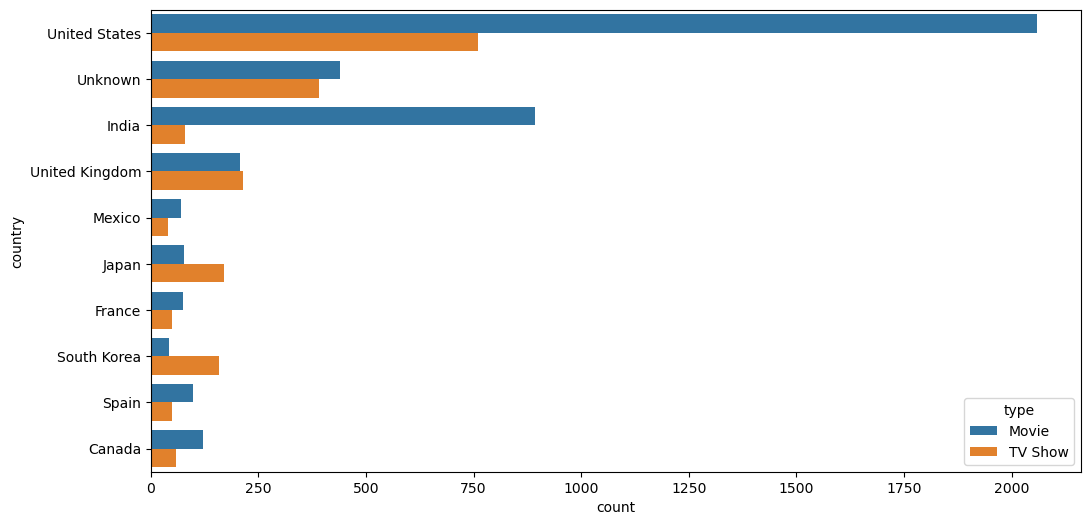

In [216]:
filtered_df = df[df['country'].isin(top_countries)]

sns.countplot(y='country',hue='type',data=filtered_df)

### Obervation : The most of the netflix releases from the US and the most releases types is  Movie than, Movie dominates in most of the countries like US. India , Some Unknown etc & Some Countries like UK, Japan, South korea has most releases in Tv shows 

<Axes: xlabel='type', ylabel='release_year'>

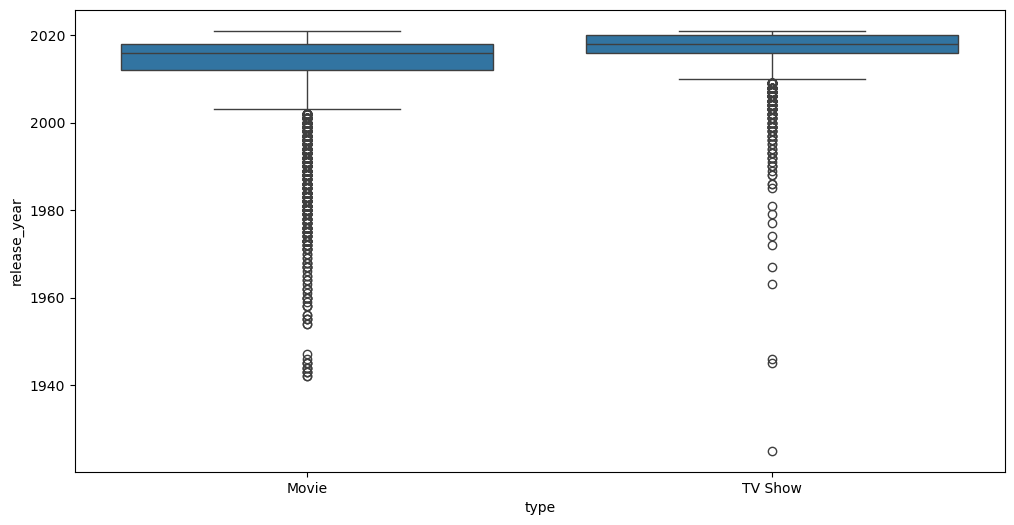

In [217]:
sns.boxplot(x='type',y='release_year',data=df)

### Observation : The Contents of Netflix Releases are more newer in the past is TV Shows as we can see the Moives has the most outliers means the most releases are older then TV shows which are in recent years 

In [218]:
top_countries = df['country'].value_counts().head(10).index
top_ratings = df['rating'].value_counts().head(5).index

<Axes: xlabel='country', ylabel='count'>

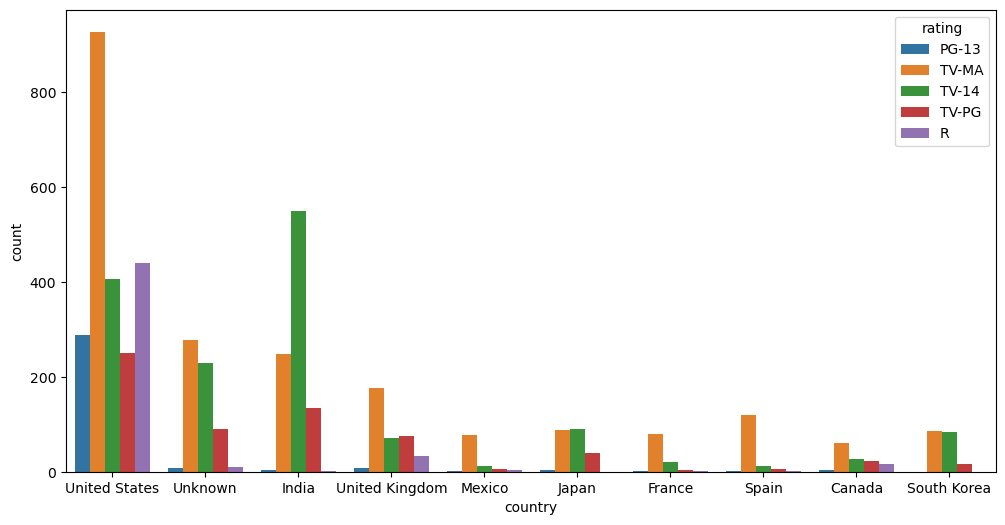

In [219]:
filtered_df = df[df['country'].isin(top_countries) & df['rating'].isin(top_ratings)]
sns.countplot(x='country',hue='rating',data=filtered_df)

### Take top 10 countries and top 5 ratings to observe from which countries which ratings are most 
### Observation : The Most the Netflix Content Releases are form US and the raitings most rated is TV MA  means mature audience in most of the countries, Countries like india and japan has most ratings in TV-14 category

In [220]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


In [221]:
movies = df[df['type'] == 'Movie']

Text(0.5, 0, 'Duration (minutes)')

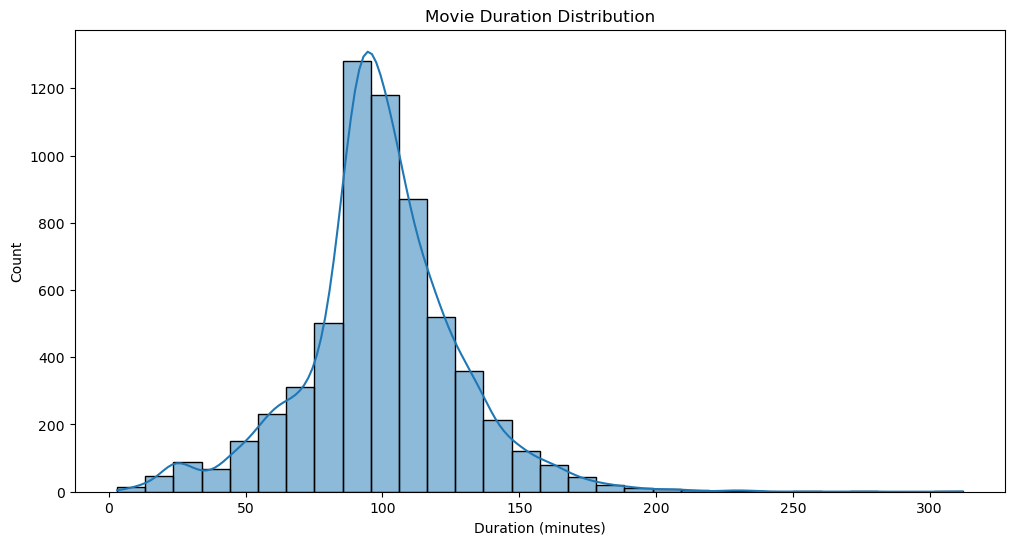

In [222]:
# Keep only rows where duration actually contains 'min'
movies = movies[movies['duration'].str.contains('min', na=False)].copy()

movies['duration_int'] = movies['duration'].str.replace(' min', '').astype(int)

sns.histplot(movies['duration_int'], bins=30, kde=True)
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')


### Observation : Most Netflix movies have a duration between 90–100 minutes.
### The peak is around 100 minutes with approximately 1200 movies.
### The distribution is right-skewed — very few movies exceed 200 minutes, indicating that extremely long movies are rare on Netflix.

Text(0.5, 0, 'Number of Seasons')

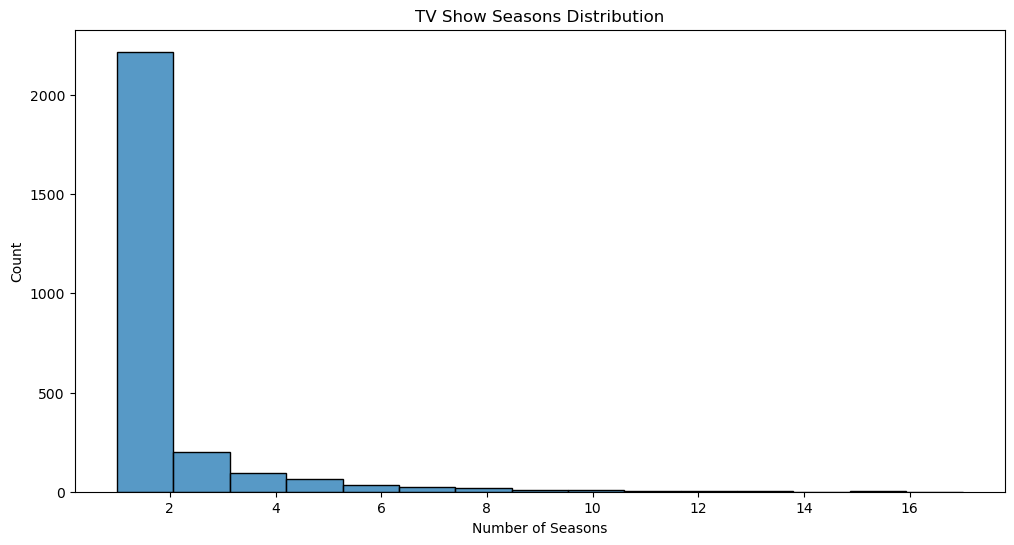

In [223]:
shows = df[df['type'] == 'TV Show'].copy()
shows['duration_int'] = shows['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

sns.histplot(shows['duration_int'], bins=15)
plt.title('TV Show Seasons Distribution')
plt.xlabel('Number of Seasons')


### Observation : Most of the Netflix TV shows has 1 Seasons almost 2000-2200 shows
### The plots looks like rigth skewed means very less shows has the season more 8 hardly 
### the most of the netflix tv shows are made for only 1 season

In [224]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='object')

Text(0.5, 1.0, 'Top 10 Genres by Type')

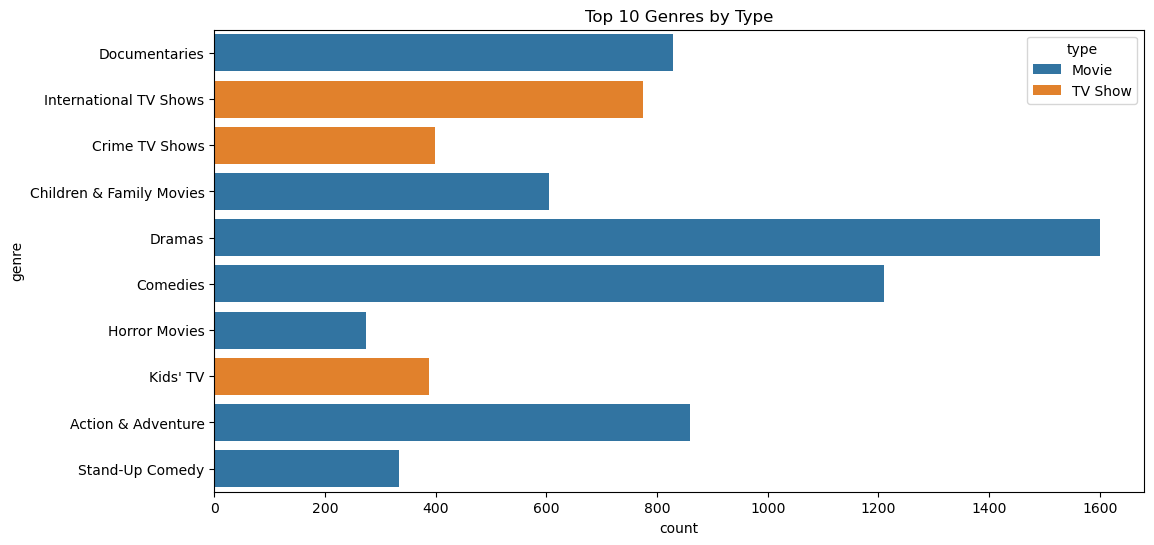

In [225]:
df['genre'] = df['listed_in'].str.split(',').str[0]

top_genres = df['genre'].value_counts().head(10).index
genre_df = df[df['genre'].isin(top_genres)]

sns.countplot(y='genre', hue='type', data=genre_df)
plt.title('Top 10 Genres by Type')

### Observation : the most of the netflix Movie releases has the listed category in dramas almost 1600s
### the most of the netflix TV shows releases has the listed category in International TV shows almost 700
### the listed category Comdies are in Movie also horror movies, action& adventure, Stand-up comedy, children & family movies, documentries
### while crime tv shows, kid's tv has most releases in tv shows category


In [226]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      98
genre            0
dtype: int64

In [227]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,Docuseries
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,International TV Shows


# Handling Missing Values

In [228]:
# Only when doing time-based analysis
df_time = df.dropna(subset=['year_added']) # >>> here we have removed the nan from year_added and stored in df_time
# the Nan in date_added if we cant perform the any operation then it won't affect the plot for now we can skip it...

In [229]:
df['month']=df['date_added'].dt.month
df['month']

0        9.0
1        9.0
2        9.0
3        9.0
4        9.0
        ... 
8802    11.0
8803     7.0
8804    11.0
8805     1.0
8806     3.0
Name: month, Length: 8807, dtype: float64

# Encoding

In [230]:
# Drop the Useless Columns for our ML Model 
df = df.drop('show_id',axis=1)
df = df.drop('title', axis=1)
df = df.drop('director', axis=1)
df = df.drop('cast', axis=1)
df = df.drop('date_added', axis=1)


In [231]:
print(df['type'].unique())

['Movie' 'TV Show']


In [232]:
df['type']=df['type'].map({'TV Show':0,'Movie':1})
df['type']

0       1
1       0
2       0
3       0
4       0
       ..
8802    1
8803    0
8804    1
8805    1
8806    1
Name: type, Length: 8807, dtype: int64

In [233]:
pd.get_dummies(df,columns=['rating'],drop_first=True)

,type,country,release_year,duration,listed_in,description,year_added,genre,month,rating_74 min,...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,1,United States,2020,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,Documentaries,9.0,False,...,True,False,False,False,False,False,False,False,False,False
1,0,South Africa,2021,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,International TV Shows,9.0,False,...,False,False,False,False,True,False,False,False,False,False
2,0,Unknown,2021,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,Crime TV Shows,9.0,False,...,False,False,False,False,True,False,False,False,False,False
3,0,Unknown,2021,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,Docuseries,9.0,False,...,False,False,False,False,True,False,False,False,False,False
4,0,India,2021,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,International TV Shows,9.0,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,1,United States,2007,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,Cult Movies,11.0,False,...,False,True,False,False,False,False,False,False,False,False
8803,0,Unknown,2018,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019.0,Kids' TV,7.0,False,...,False,False,False,False,False,False,False,True,False,False
8804,1,United States,2009,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,Comedies,11.0,False,...,False,True,False,False,False,False,False,False,False,False
8805,1,United States,2006,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,Children & Family Movies,1.0,False,...,False,False,False,False,False,False,False,False,False,False


## What drop_first=True does:
### If rating has 10 categories → normally creates 10 new columns.
### drop_first=True → drops the first category column → creates only 9 columns.
### Why? — To avoid multicollinearity in ML models. If you know 9 categories, the 10th is automatically known. So one column is redundant.
### This comes under → One Hot Encoding
##  One Hot Encoding converts a categorical column into multiple binary (0/1) columns.One Hot Encoding converts a categorical column into multiple binary (0/1) columns.

In [234]:
df.columns

Index(['type', 'country', 'release_year', 'rating', 'duration', 'listed_in',
       'description', 'year_added', 'genre', 'month'],
      dtype='object')

In [235]:
pd.get_dummies(df,columns=['genre'],drop_first=True)

,type,country,release_year,rating,duration,listed_in,description,year_added,month,genre_Anime Features,...,genre_Sports Movies,genre_Stand-Up Comedy,genre_Stand-Up Comedy & Talk Shows,genre_TV Action & Adventure,genre_TV Comedies,genre_TV Dramas,genre_TV Horror,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_Thrillers
0,1,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,False,...,False,False,False,False,False,False,False,False,False,False
1,0,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,False,...,False,False,False,False,False,False,False,False,False,False
2,0,Unknown,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,False,...,False,False,False,False,False,False,False,False,False,False
3,0,Unknown,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,False,...,False,False,False,False,False,False,False,False,False,False
4,0,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,1,United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,11.0,False,...,False,False,False,False,False,False,False,False,False,False
8803,0,Unknown,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019.0,7.0,False,...,False,False,False,False,False,False,False,False,False,False
8804,1,United States,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,11.0,False,...,False,False,False,False,False,False,False,False,False,False
8805,1,United States,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,1.0,False,...,False,False,False,False,False,False,False,False,False,False


In [236]:
df = pd.get_dummies(df,columns=['country','rating','listed_in'],drop_first=True)
df.head()

,type,release_year,duration,description,year_added,genre,month,"country_, South Korea",country_Argentina,"country_Argentina, Brazil, France, Poland, Germany, Denmark",...,"listed_in_TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","listed_in_TV Dramas, TV Thrillers","listed_in_TV Dramas, Teen TV Shows","listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers
0,1,2020,90 min,"As her father nears the end of his life, filmm...",2021.0,Documentaries,9.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,2021,2 Seasons,"After crossing paths at a party, a Cape Town t...",2021.0,International TV Shows,9.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2021,1 Season,To protect his family from a powerful drug lor...,2021.0,Crime TV Shows,9.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,2021,1 Season,"Feuds, flirtations and toilet talk go down amo...",2021.0,Docuseries,9.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2021,2 Seasons,In a city of coaching centers known to train I...,2021.0,International TV Shows,9.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Correlation Heatmap

<Axes: >

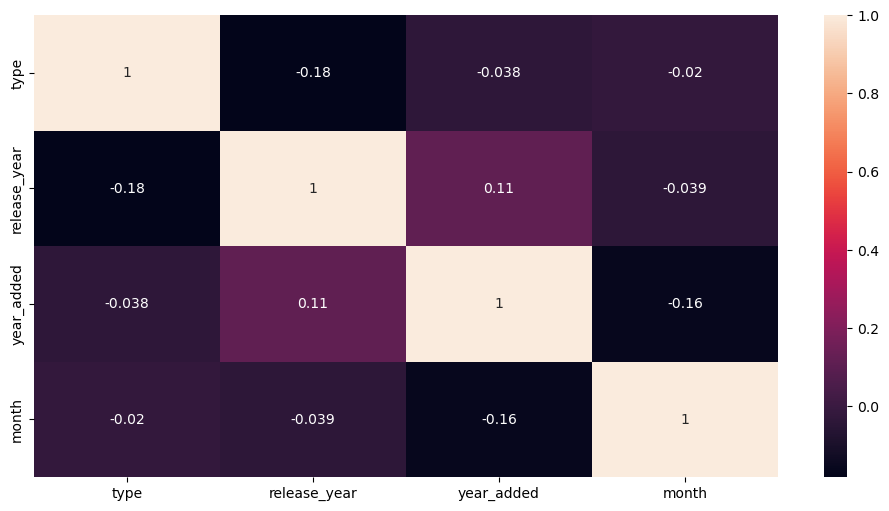

In [237]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

### Correlation Pair	Value
### type ↔ release_year	-0.18
### type ↔ year_added	-0.038
### type ↔ month	-0.02
### release_year ↔ year_added	0.11
### release_year ↔ month	-0.039
### year_added ↔ month	-0.16

In [238]:
df = df.drop('duration',axis=1)

In [244]:
df = df.drop('description',axis=1)

In [251]:
df.select_dtypes(include='object').columns

Index(['genre'], dtype='object')

In [252]:
df = pd.get_dummies(df, columns=['genre'], drop_first=True)

# Feature & Target Seperation

In [253]:
X=df.drop('type',axis=1)
y=df['type']

In [254]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)


In [255]:
X_test.columns

Index(['release_year', 'year_added', 'month', 'country_, South Korea',
       'country_Argentina',
       'country_Argentina, Brazil, France, Poland, Germany, Denmark',
       'country_Argentina, Chile', 'country_Argentina, Chile, Peru',
       'country_Argentina, France',
       'country_Argentina, France, United States, Germany, Qatar',
       ...
       'genre_Sports Movies', 'genre_Stand-Up Comedy',
       'genre_Stand-Up Comedy & Talk Shows', 'genre_TV Action & Adventure',
       'genre_TV Comedies', 'genre_TV Dramas', 'genre_TV Horror',
       'genre_TV Sci-Fi & Fantasy', 'genre_TV Shows', 'genre_Thrillers'],
      dtype='object', length=1315)

In [256]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
# Next step is ML model 

In [257]:
df.head()

,type,release_year,year_added,month,"country_, South Korea",country_Argentina,"country_Argentina, Brazil, France, Poland, Germany, Denmark","country_Argentina, Chile","country_Argentina, Chile, Peru","country_Argentina, France",...,genre_Sports Movies,genre_Stand-Up Comedy,genre_Stand-Up Comedy & Talk Shows,genre_TV Action & Adventure,genre_TV Comedies,genre_TV Dramas,genre_TV Horror,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_Thrillers
0,1,2020,2021.0,9.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,2021,2021.0,9.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2021,2021.0,9.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,2021,2021.0,9.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2021,2021.0,9.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
